# IAA Study

In [ ]:
!python -m pip install --upgrade pandas statsmodels

In [1]:
from pathlib import Path

root_dir = Path.home() / 'moralization'

In [12]:
import pandas as pd

df = pd.read_csv(root_dir / 'data/iaa-study_test-150.tsv', sep="\t")

In [14]:
import json

with (root_dir / 'data/predictions.json').open() as f:
    pred = json.load(f)
len(pred)

70

In [15]:
models = ['claude', 'gpt-5', 'cohere', 'llama', 'mistral']

experiments = [
    'basic_json_0shot',
    'cot_json_0shot',
    'cot_json-explain_0shot',
    'cot_json_10shot',
    'cot_json-explain_10shot',
    'manual_json_0shot',
    'manual_json-explain_0shot',
]

In [16]:
for exp in experiments:
    for model in models:
        name = f'{exp}_{model}_test-150'
        p = {d['text_id']: int(d['output']['moralisierung']['enthaelt_moralisierung']) for d in pred[name]}
        df[name] = df['text_id'].apply(lambda x: p[x])
df.head(5)

,text_id,Expert 1,Expert 2,Expert 3,Student Assistant 1,Student Assistant 2,Majority Vote,basic_json_0shot_claude_test-150,basic_json_0shot_gpt-5_test-150,basic_json_0shot_cohere_test-150,...,manual_json_0shot_claude_test-150,manual_json_0shot_gpt-5_test-150,manual_json_0shot_cohere_test-150,manual_json_0shot_llama_test-150,manual_json_0shot_mistral_test-150,manual_json-explain_0shot_claude_test-150,manual_json-explain_0shot_gpt-5_test-150,manual_json-explain_0shot_cohere_test-150,manual_json-explain_0shot_llama_test-150,manual_json-explain_0shot_mistral_test-150
0,them-Interviews-neg-0288,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,them-Kommentare-neg-0344,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,them-Plenar-pos-0435,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
3,mor-Leserbriefe-neg-0460,1,0,1,0,1,1,1,1,0,...,1,0,0,0,1,1,1,0,0,1
4,mor-Kommentare-pos-0186,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [17]:
experts = ['Expert 1', 'Expert 2', 'Expert 3']
assistants = ['Student Assistant 1', 'Student Assistant 2']
humans = ['Expert 1', 'Expert 2', 'Expert 3', 'Student Assistant 1', 'Student Assistant 2']
label_legends = {
    'All Humans': experts + assistants,
    'Experts': experts,
    'Student Assistants': assistants,
    'Claude': [x for x in df.columns if 'claude' in x],
    'GPT-5': [x for x in df.columns if 'gpt-5' in x],
    'Cohere': [x for x in df.columns if 'cohere' in x],
    'Llama': [x for x in df.columns if 'llama' in x],
    'Mistral': [x for x in df.columns if 'mistral' in x],
    'All LLMs': [x for x in df.columns if 'test-150' in x],
    'cot': [x for x in df.columns if 'cot_json_0shot' in x],
    'cot_10shot': [x for x in df.columns if 'cot_json_10shot' in x],
    'cot-explain': [x for x in df.columns if 'cot_json-explain_0shot' in x],
    'cot-explain_10shot': [x for x in df.columns if 'cot_json-explain_10shot' in x],
    'manual': [x for x in df.columns if 'manual_json_0shot' in x],
    'manual-explain': [x for x in df.columns if 'manual_json-explain_0shot' in x],
    'Humans + LLMs': humans + [x for x in df.columns if 'test-150' in x],
    'Experts + LLMs': experts + [x for x in df.columns if 'test-150' in x],
    'Student Assistants + LLMs': assistants + [x for x in df.columns if 'test-150' in x],
    'Humans + Claude': humans + [x for x in df.columns if 'claude' in x],
    'Humans + GPT-5': humans + [x for x in df.columns if 'gpt-5' in x],
    'Humans + Cohere': humans + [x for x in df.columns if 'cohere' in x],
    'Humans + Llama': humans + [x for x in df.columns if 'llama' in x],
    'Humans + Mistral': humans + [x for x in df.columns if 'mistral' in x],
}

#### Fleiß

In [18]:
from statsmodels.stats.inter_rater import fleiss_kappa
def compute_group_fleiss(df, annotators):
    xdf = df[annotators]
    xdf['True'] = xdf.aggregate(sum, axis=1)
    xdf['False'] = xdf['True'].apply(lambda x: len(annotators) - x)
    kappa = fleiss_kappa(xdf[['True', 'False']].values)
    return float(kappa)

In [ ]:
fleiss = {label: compute_group_fleiss(df, anno) for label, anno in label_legends.items()}

#### Pair-wise PABAK
Based on this code: https://github.com/maciejskorski/moral-foundations-llm-eval/blob/main/src/annots_competences.ipynb

In [21]:
import numpy as np
from itertools import combinations

def pairwise_pabak(df, annotators):
    annotations = df[annotators].to_numpy()
    n_annotators = annotations.shape[1]
    pabak_scores = []
    annotator_pairs = []
    for a1, a2 in combinations(range(n_annotators), 2):
        y1, y2 = annotations[:, a1], annotations[:, a2]
        mask = ~(np.isnan(y1) | np.isnan(y2))
        if np.sum(mask) == 0:
            continue
        po = np.mean(y1[mask] == y2[mask])
        pabak_scores.append(2 * po - 1)
        annotator_pairs.append((a1, a2))
    return np.nanmean(pabak_scores), pabak_scores, annotator_pairs

def compute_pairwise_pabak(df, annotators):
    mean_pabak, individual_pabaks, annotator_pairs = pairwise_pabak(df, annotators)
    
    # Get annotator names from DataFrame columns
    #annotator_names = df.columns.tolist()
    
    ratings = np.empty((len(annotators), len(annotators)))
    #print(f"Mean Pairwise PABAK: {mean_pabak}")
    #print("*"* 50)
    #print("Individual Pairwise PABAKs:")
    for (a1, a2), score in zip(annotator_pairs, individual_pabaks):
        #print(f"{annotators[a1]} vs {annotators[a2]}: {score}")
        ratings[a2, a1] = score
        ratings[a1, a2] = score
    return ratings

In [22]:
pabak = {label: pairwise_pabak(df, anno)[0] for label, anno in label_legends.items()}

In [24]:
group_metric = pd.DataFrame({
    'Fleiss': fleiss.values(),
    'PABAK': pabak.values()
}, index=label_legends.keys())
group_metric

,Fleiss,PABAK
All Humans,0.556551,0.610667
Experts,0.679306,0.697778
Student Assistants,0.474986,0.613333
Claude,0.671631,0.739683
GPT-5,0.736126,0.740952
Cohere,0.676705,0.680000
Llama,0.551648,0.553016
Mistral,0.739694,0.775238
All LLMs,0.588786,0.605423
cot,0.527970,0.528000


In [27]:
label_colors = {
    'All Humans': 'lightslategray',
    'Experts': 'lightslategray',
    'Student Assistants': 'lightslategray',
    'Claude': 'blue',
    'GPT-5': 'blue',
    'Cohere': 'blue',
    'Llama': 'blue',
    'Mistral': 'blue',
    'All LLMs': 'blue',
    'cot': 'green',
    'cot_10shot': 'green',
    'cot-explain': 'green',
    'cot-explain_10shot': 'green',
    'manual': 'green',
    'manual-explain': 'green',
    'Humans + LLMs': 'red',
    'Experts + LLMs': 'red',
    'Student Assistants + LLMs': 'red',
    'Humans + Claude': 'orange',
    'Humans + GPT-5': 'orange',
    'Humans + Cohere': 'orange',
    'Humans + Llama': 'orange',
    'Humans + Mistral': 'orange',
}

In [41]:
import plotly.graph_objects as go

def bar_plot(ratings, title):
    x, y = zip(*ratings.items())
    fig = go.Figure(data=[go.Bar(
        x=x,
        y=y,
        text=[f'{i:.02f}' for i in y],
        marker_color=[label_colors[l] for l in x]
    )])
    fig.update_layout(title_text=title, width=1000, height=400)
    fig.write_image(root_dir / f'docs/img/group_{title.lower()}.png')
    fig.write_image(root_dir / f'docs/img/group_{title.lower()}.pdf')
    fig.show()

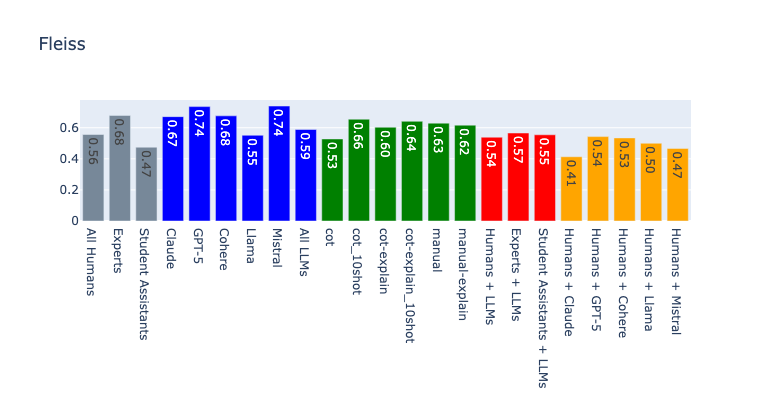

In [28]:
bar_plot(fleiss, title="Fleiss")

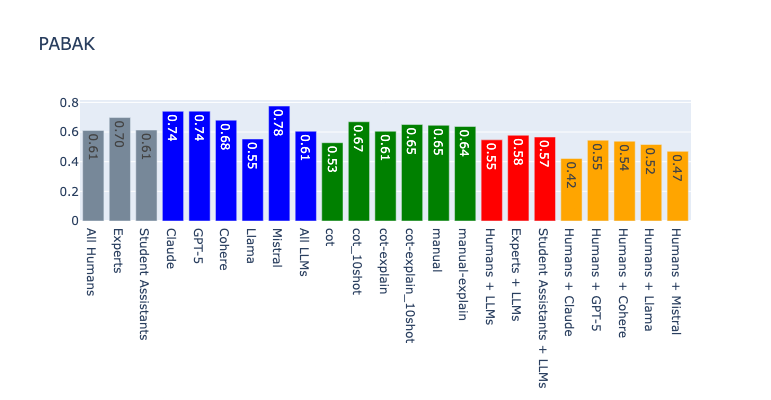

In [42]:
bar_plot(pabak, title="PABAK")

In [30]:
import plotly.express as px

def plot_heatmap(ratings, title, labels, cmin=0.3, cmax=0.85):
    
    corr = pd.DataFrame(ratings, index=labels, columns=labels).apply(lambda x: np.round(x, 3))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    df_mask = corr.mask(mask)
    
    fig = px.imshow(df_mask, text_auto=True, color_continuous_scale='RdBu_r')
    fig.update_xaxes(side="bottom")
    
    fig.update_layout(
        title_text=title, 
        #title_x=0.5,
        title_y=0.9,
        width=500, 
        height=500,
        xaxis_showgrid=False,
        yaxis_showgrid=False,
        xaxis_zeroline=False,
        yaxis_zeroline=False,
        yaxis_autorange='reversed',
        template='plotly_white',
        coloraxis={'cmin': cmin, 'cmax': cmax},
        coloraxis_colorbar={'len': 0.8}
    )
    
    # NaN values are not handled automatically and are displayed in the figure
    # So we need to get rid of the text manually
    for i in range(len(fig.layout.annotations)):
        if fig.layout.annotations[i].text == 'nan':
            fig.layout.annotations[i].text = ""
    
    fig.show()
    fig.write_image(root_dir / f"results/img/{title.replace(' ', '-')}.png") 

In [ ]:
import numpy as np

ratings = np.empty((len(humans), len(humans)))
for i, a in enumerate(humans):
    for j, b in enumerate(humans):
        ratings[i, j] = compute_group_fleiss(df, [a, b]) if a != b else float('nan')

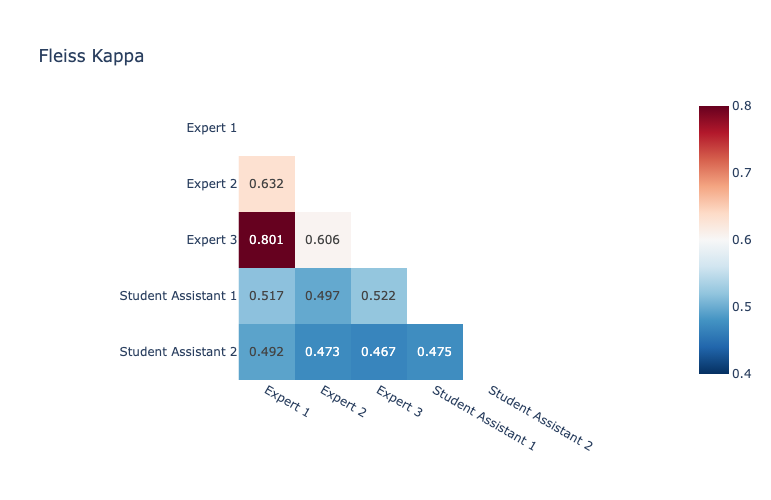

In [33]:
plot_heatmap(ratings, 'Fleiss Kappa', labels=humans, cmin=0.4, cmax=0.8)

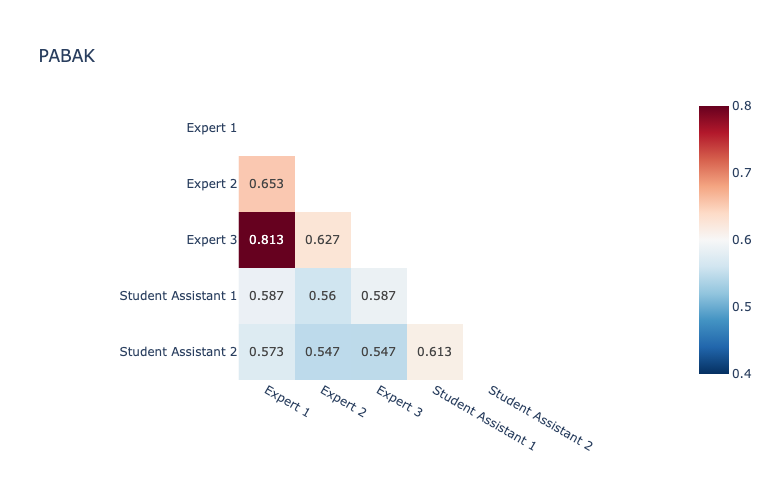

In [34]:
ratings = compute_pairwise_pabak(df, humans)
plot_heatmap(ratings, 'PABAK', labels=humans, cmin=0.4, cmax=0.8)

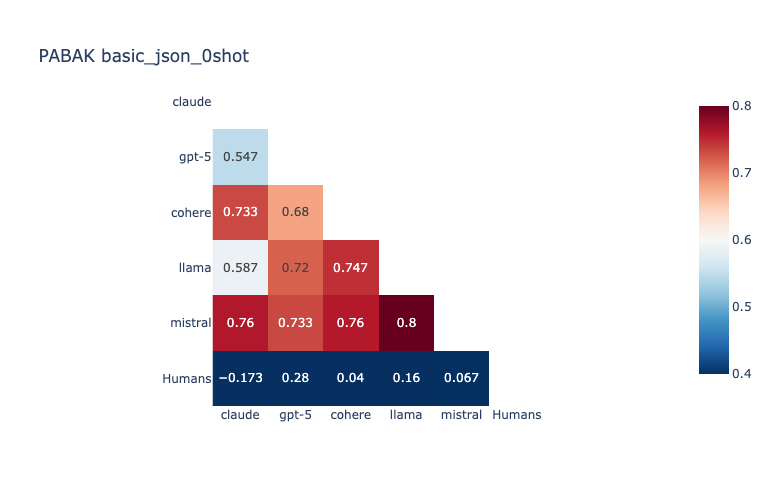

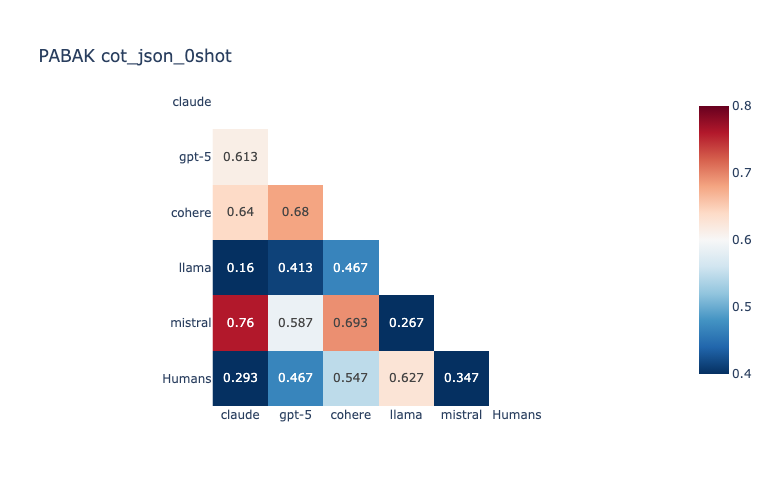

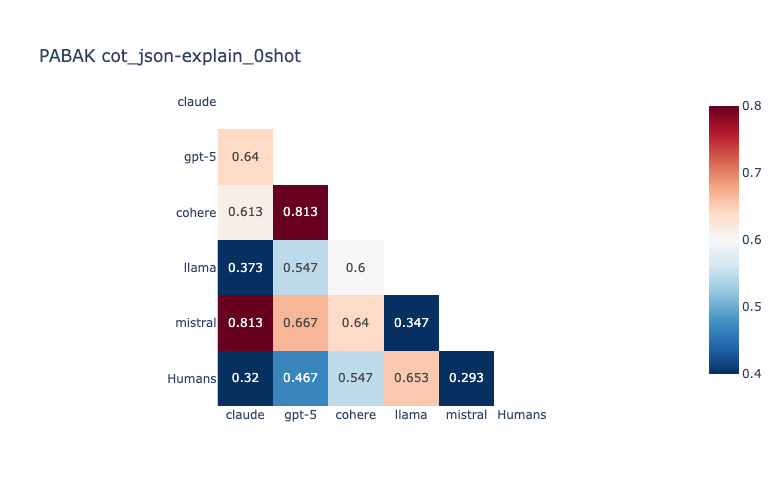

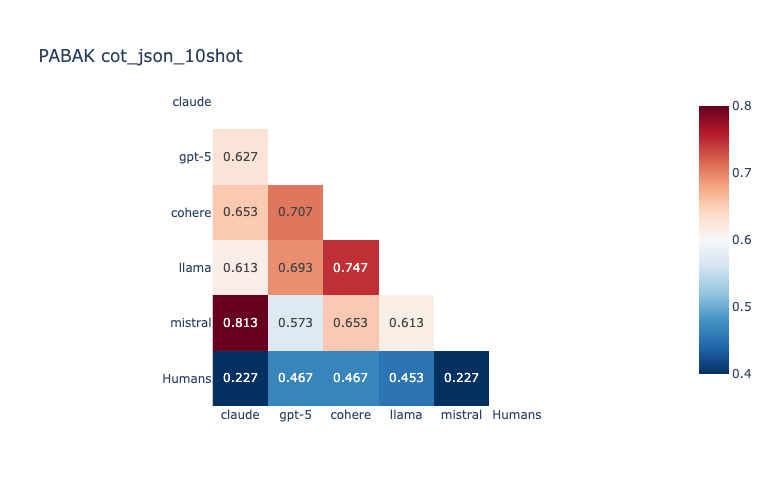

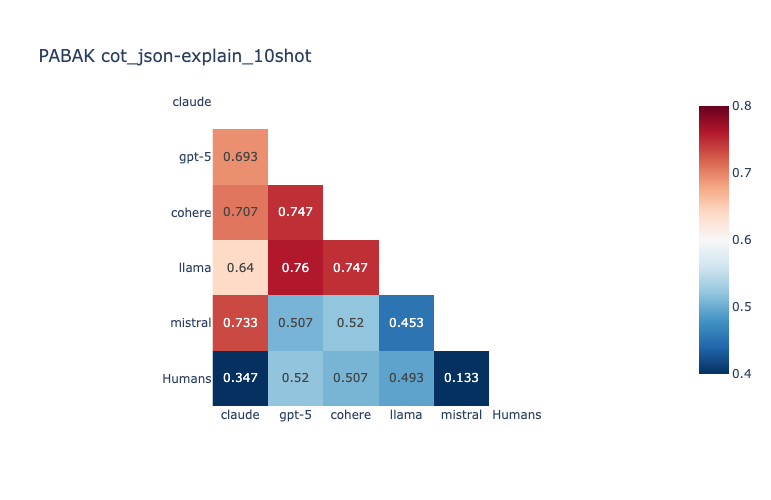

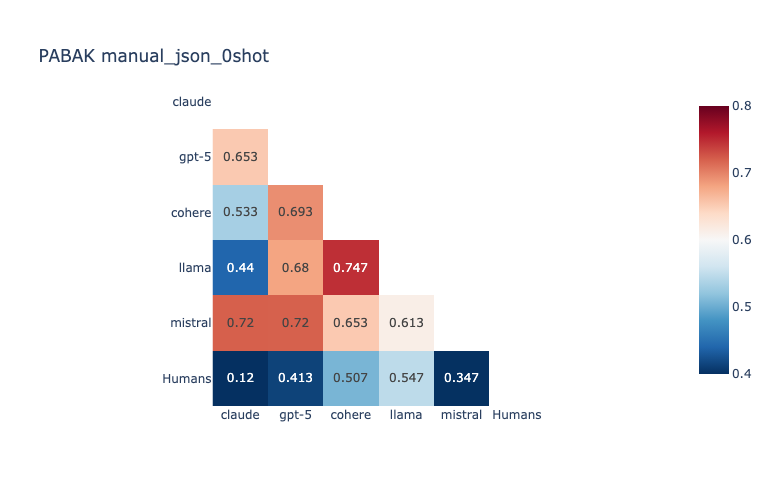

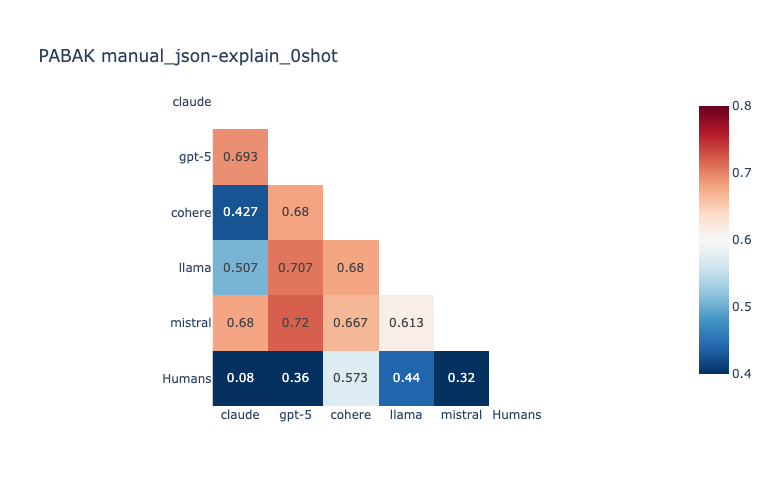

In [36]:
for exp in experiments:
    llms = [f'{exp}_{model}_test-150' for model in models] + ['Majority Vote']
    labels = models + ['Humans']
    ratings = compute_pairwise_pabak(df, llms)
    plot_heatmap(ratings, f'PABAK {exp}', labels=labels, cmin=0.4, cmax=0.8)

#### Calculate Dawid-Skene
Uses the code from: https://github.com/kajyuuen/Dawid-skene

In [37]:
from dawid_skene_model import list2array, DawidSkeneModel

def compute_dawid_skene(df, annotators):
    # Prepare dataset in Dawid-Skene format (list of lists of lists)
    class_num = 2 # Number of classes (0 and 1)
    dataset_list = []
    for row in df[annotators].itertuples(index=False):
        task = []
        for label in row:
            task.append([int(label)])  
        dataset_list.append(task)
    
    # Calculate Dawid-Skene
    dataset_tensor = list2array(class_num, dataset_list)
    model = DawidSkeneModel(class_num, max_iter=45, tolerance=1e-10)
    marginal_predict, error_rates, worker_reliability, predict_label = model.run(dataset_tensor)
    
    #print("Dawid-Skene Marginal Class Probabilities (mean across tasks):")
    #sorted_classes = sorted(enumerate(marginal_predict), key=lambda x: x[1], reverse=True)
    #for i, prob in sorted_classes:
    #    print(f"  Class {i}: {prob:.4f}")
    #print("*" * 50)
    #print("Worker Reliability:")
    #annotator_names = df.columns.tolist()
    sorted_workers = sorted(worker_reliability.items(), key=lambda x: x[1], reverse=True)
    #for i, reliability in sorted_workers:
    #    print(f"  {annotators[i]}: {reliability:.4f}")
    return {annotators[i]: float(reliability) for i, reliability in sorted_workers}, predict_label.argmax(axis=1).tolist()

In [38]:
scores, labels = compute_dawid_skene(df, humans)

In [39]:
print('|annotators|' + '|'.join(humans) + '|')
print('|:--|--:|--:|--:|--:|--:|')
print(f'|annotator', end="")
for _, s in scores.items():
    print(f'|{s:.4f}', end="")
print('|')

|annotators|Expert 1|Expert 2|Expert 3|Student Assistant 1|Student Assistant 2|
|:--|--:|--:|--:|--:|--:|
|annotator|0.9518|0.9429|0.8535|0.8225|0.7846|


|annotators|Expert 1|Expert 2|Expert 3|Student Assistant 1|Student Assistant 2|
|:--|--:|--:|--:|--:|--:|
|annotator|0.9518|0.9429|0.8535|0.8225|0.7846|

In [40]:
print('|prompt|' + '|'.join(models) + '|')
print('|:--|--:|--:|--:|--:|--:|')
for exp in experiments:
    llms = [f'{exp}_{model}_test-150' for model in models]
    scores, labels = compute_dawid_skene(df, llms)
    print(f'|{exp}', end="")
    for model in models:
        s = scores[f'{exp}_{model}_test-150']
        print(f'|{s:.4f}', end="")
    print('|')

|prompt|claude|gpt-5|cohere|llama|mistral|
|:--|--:|--:|--:|--:|--:|
|basic_json_0shot|0.8331|0.9055|0.9096|0.9431|0.9531|
|cot_json_0shot|0.9003|0.8571|0.9197|0.6797|0.9195|
|cot_json-explain_0shot|0.8807|0.9378|0.9258|0.7524|0.8941|
|cot_json_10shot|0.9149|0.8927|0.9090|0.8886|0.8917|
|cot_json-explain_10shot|0.9219|0.9240|0.9157|0.8973|0.8293|
|manual_json_0shot|0.8286|0.9263|0.9040|0.8866|0.9033|
|manual_json-explain_0shot|0.8467|0.9444|0.8666|0.8904|0.9078|


|prompt|claude|gpt-5|cohere|llama|mistral|
|:--|--:|--:|--:|--:|--:|
|basic_json_0shot|0.8331|0.9055|0.9096|0.9431|0.9531|
|cot_json_0shot|0.9003|0.8571|0.9197|0.6797|0.9195|
|cot_json-explain_0shot|0.8807|0.9378|0.9258|0.7524|0.8941|
|cot_json_10shot|0.9149|0.8927|0.9090|0.8886|0.8917|
|cot_json-explain_10shot|0.9219|0.9240|0.9157|0.8973|0.8293|
|manual_json_0shot|0.8286|0.9263|0.9040|0.8866|0.9033|
|manual_json-explain_0shot|0.8467|0.9444|0.8666|0.8904|0.9078|